# NBA Longitudinal Performance Analysis

## Problem Statement

#### How stable are individual NBA performance metrics across seasons, and which stats are most predictive of future performance?

I've been an avid sports fan my entire life and going to university sparked a passion for college and professional basketball. I love looking at statistics to predict the next games' outcomes, and this question allows me to learn more about the sport in the past three decades while putting my programming and statistics skills to use. There are lots of stats to consider in basketball, from points to assists to rebounds to minutes played, so knowing which are the most important is an interesting research question that I would love to find more about.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

This data set contains over 20 years of data on each player who has been a part of an NBA teams' roster. It contains demographics such as age, height, weight, and place of birth as well as game statistics like average points, assists, rebounds, and games played. It also has draft year, round, team played for, and other biographicals.

Dataset credits to Kaggle user Justinas Cirtautas.

In [82]:
nba_data = pd.read_csv("../data/raw/nba_player_stats.csv", index_col=0)

nba_data.head()

,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [83]:
# show number of rows and columns, respectively
nba_data.shape

(12844, 21)

In [84]:
# all column names in the dataframe
nba_data.columns

Index(['player_name', 'team_abbreviation', 'age', 'player_height',
       'player_weight', 'college', 'country', 'draft_year', 'draft_round',
       'draft_number', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'oreb_pct',
       'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct', 'season'],
      dtype='object')

Player identifier: ```"player_name"```
Season variable: ```"season"```
Season time variable: ```"gp"```

In [85]:
# number of unique players in the NBA since the 1997 season
nba_data["player_name"].nunique()

2551

In [86]:
nba_data.mean(numeric_only=True)

age               27.045313
player_height    200.555097
player_weight    100.263279
gp                51.154158
pts                8.212582
reb                3.558486
ast                1.824681
net_rating        -2.226339
oreb_pct           0.054073
dreb_pct           0.140646
usg_pct            0.184641
ts_pct             0.513138
ast_pct            0.131595
dtype: float64



## Unit of Observation

Players' season composite z-score of box statistics (points, rebounds, assists, etc.)

## Outcome variable

Players' future season statistics (" ")

This is a good measurement because it includes statistics that typically indicate a good player (scores a lot, is a team player, aggressive in the paint). We can then use the trends to predict whether a player will have a similar season the next year, should he play. We can also analyze what statistics early will lead to a long career in the NBA, or if early-career burnout is real.

## Key Assumptions

More games played creates more opportunity for players to learn and shine; better teams can inflate individual stats

## What Could Go Wrong

Position changes; survivorship bias; mid-season injuries; lack of defensive statistics

## What this dataset allows me to do:

I can track the offensive statistics of players across seasons and determine what statistics indicate a longer season in the NBA.
I can analyze trends within the statistics across seasons to find patterns between players, positions, and teams.
I can identify revolutions such as the three point revolution due to dynamic changes in box stats across the league.

## What is this dataset does not allow me to do:

I can't track defensive statistics.
I won't know if a player leaves the NBA for a purpose other than performance issues such as injury, bad team chemistry, inactivity, etc.
It won't be as good at predictive modeling for a specific player against a specific team, due to not knowing individual game statistics, only season ones.

## Initial Expectations:

I believe the most stable stats across the seasons will be games played, not necessarily by player but the general distribution. You will have your starters who play most games, your backups who play maybe half the games, and then the bench players who are only getting playing time when multiple people are injured or an opponent is getting blown out. This statistic can't change much because unlike the other statistics, there is a ceiling to the number of games a team can play in a ceiling. While there is a theoretical limit on other statistics, it depends on the team, the era, the seasonal dominance, etc. I also think age will be generally stable because biology tells us men peak at age 25.

In [87]:
missing_counts = nba_data.isnull().sum()

print(missing_counts)

player_name             0
team_abbreviation       0
age                     0
player_height           0
player_weight           0
college              1854
country                 0
draft_year              0
draft_round             0
draft_number            0
gp                      0
pts                     0
reb                     0
ast                     0
net_rating              0
oreb_pct                0
dreb_pct                0
usg_pct                 0
ts_pct                  0
ast_pct                 0
season                  0
dtype: int64


```"college"``` is the only default feature will missing values, which makes this dataset nice to work with. These missing values are most likely due to players entering the league from an alternative program, such as the G league, OTE, or international academy.

In [88]:
print(nba_data.dtypes)

player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object


## Data Cleaning

In [89]:
# rename columns to ones that I prefer
nba_data = nba_data.rename(columns={"player_name" : "player", "team_abbreviation" : "team", "player_height" : "height", "player_weight" : "weight"})

nba_data.head()

,player,team,age,height,weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [90]:
draft_cols = ["draft_round", "draft_number", "draft_year"]

for col in draft_cols:
    nba_data[col] = (
        nba_data[col]
        .replace("Undrafted", pd.NA)
        .astype("Int64")
    )

nba_data["age"] = nba_data["age"].astype("int64")

nba_data.head()

,player,team,age,height,weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is the next step in data processing and analysis by investigating the data sets and summarizing their main characteristics using visualization, uncovering patterns, spotting irregularities, and finding interesting relationships.

I want to begin predicting a player's next season points based on their current season's statistics

In [91]:
# restructure dataframe by players
nba_data = nba_data.sort_values(["player", "season"])

# new feature "next_season_pts"
nba_data["next_season_pts"] = nba_data.groupby("player")["pts"].shift(-1)
nba_data= nba_data.dropna(subset=["next_season_pts"])

nba_data.head()




,player,team,age,height,weight,college,country,draft_year,draft_round,draft_number,...,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season,next_season_pts
419,A.C. Green,DAL,33,205.74,102.05820,Oregon State,USA,1985,1,23,...,7.9,0.8,-8.0,0.100,0.207,0.119,0.523,0.045,1996-97,7.3
667,A.C. Green,DAL,34,205.74,102.05820,Oregon State,USA,1985,1,23,...,8.1,1.5,-7.2,0.090,0.196,0.118,0.496,0.074,1997-98,4.9
1006,A.C. Green,DAL,35,205.74,102.05820,Oregon State,USA,1985,1,23,...,4.6,0.5,-5.6,0.097,0.179,0.148,0.441,0.043,1998-99,5.0
1626,A.C. Green,LAL,36,205.74,102.05820,Oregon State,USA,1985,1,23,...,5.9,1.0,8.1,0.089,0.179,0.111,0.482,0.058,1999-00,4.5
1970,A.J. Guyton,CHI,23,185.42,81.64656,Indiana,USA,2000,2,32,...,1.1,1.9,-12.4,0.018,0.053,0.169,0.495,0.198,2000-01,5.4


In [92]:
# machine learning imports

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

I need to choose features of nba_data that will accurately predict our target variable, which will be the next_season's average points-per-game

In [93]:
features = ["age", "gp", "pts", "reb", "ast", "net_rating", "oreb_pct", "dreb_pct", "usg_pct", "ts_pct", "ast_pct"]

X = nba_data[features]
y = nba_data["next_season_pts"]

In [94]:
# split data 80:20 for training and testing
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.2, random_state=5)

In [95]:
#n_estimators=100
# for estimators in [50, 100, 250, 500]:
#     model= create_model("n_estimators", estimators)
#     print(estimators, score_model(model))
#
# #max_depth=None
# for depth in [5, 10, 15, 20]:
#     model= create_model("max_depth", depth)
#     print(depth, score_model(model))
#
# #min_samples_split=2
# for sample_splits in [2, 5, 10, 20]:
#     model= create_model("min_samples_split", sample_splits)
#     print(sample_splits, score_model(model))
#
# #max_leaf_nodes=None
# for nodes in [50, 100, 250, 500]:
#     model= create_model("max_leaf_nodes", nodes)
#     print(nodes, score_model(model))
#
# #min_samples_leaf=1
# for sample_leaf in [1, 2, 5, 10]:
#     model = create_model("min_samples_leaf", sample_leaf)
#     print(sample_leaf, score_model(model))

Best Individual Argument: min_samples_leaf=2, all other defaults

### First Model

Using RandomForest because it is the most consistent model I have learned about so far. Using all defaults to get a baseline model and random state for consistency (5 is my favorite number)

In [96]:
model = RandomForestRegressor(random_state=5)

model.fit(train_X, train_y)
preds = model.predict(val_X)

mae = mean_absolute_error(val_y, preds)
print("MAE:", mae)


MAE: 2.3431243322000967


Mean Average Error: 2.343

Interpretation: Our model is, on average, predicting player's next season's average points per game 2.3 points away from what they actually are.

Now we can figure out which features were the most important in this model's evaluation:

In [97]:
important_features = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(important_features)

pts           0.765127
age           0.034535
net_rating    0.032337
usg_pct       0.026379
gp            0.026104
ts_pct        0.025912
oreb_pct      0.020784
dreb_pct      0.020057
ast_pct       0.019709
reb           0.015118
ast           0.013938
dtype: float64


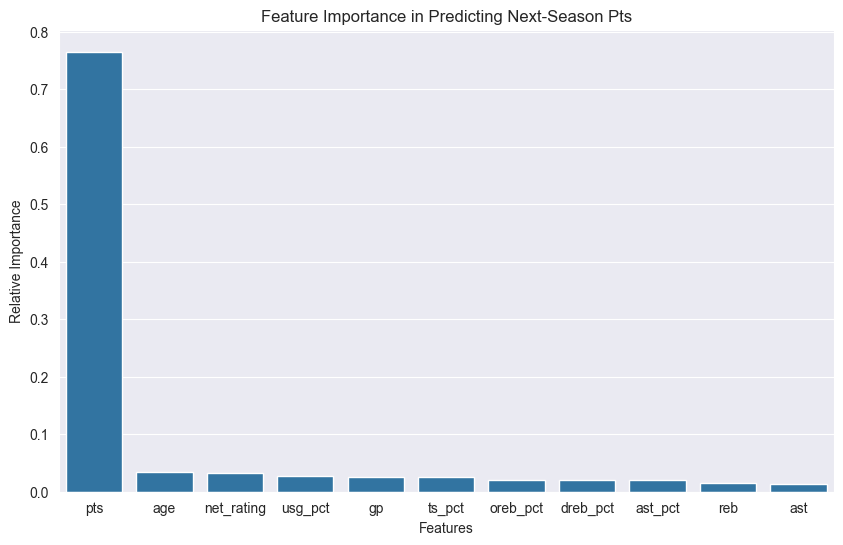

In [98]:
plt.figure(figsize=(10,6))

plt.title("Feature Importance in Predicting Next-Season Pts")

sns.barplot(x=important_features.index, y=important_features)

plt.xlabel("Features")
plt.ylabel("Relative Importance")

plt.show()

Average points-per-game scored by players dominates feature importance in our first model, which is exactly what I would expect, as good scorers will usually continue scoring.

Now what if we train it without points?

In [99]:
# create training function to eliminate repetitive code

def train_model(feature_list: list, params: dict = None):
    """
    Trains a RandomForestRegressor model for the nba_data and returns the trained model and mean average error (MAE)
    Can take in a feature list and parameter dictionary

    :param feature_list: list of features that the model will evaluate with
    :param params: dictionary of parameters to pass to the model

    :return: (trained model, MAE)
    """

    # default parameters, used from Kaggle lessons
    if params is None:
        params = {
            "n_estimators": 100,
            "min_samples_leaf": 2,
            "random_state": 5
        }


    featured_data = nba_data[feature_list]
    y = nba_data["next_season_pts"]

    x_train, x_val, y_train, y_val = train_test_split(
        featured_data, y, test_size=0.2, random_state=5
    )

    featured_model = RandomForestRegressor(**params)
    featured_model.fit(x_train, y_train)

    feature_pred = featured_model.predict(x_val)
    mae = mean_absolute_error(y_val, feature_pred)

    print(f"MAE: {mae:.3f}")

    return featured_model, mae



# feature importance function

def feature_importance(input_model, feature_list):
    important_features_ = pd.Series(
        input_model.feature_importances_,
        index=feature_list
    ).sort_values(ascending=False)

    return important_features_

In [100]:
features_no_pts = [f for f in features if f != "pts"]

new_model, new_mae = train_model(features_no_pts)

MAE: 2.428


Slightly worse model but let's see the feature importance

In [103]:
important_features_nopts = feature_importance(new_model, features_no_pts)

important_features_nopts

usg_pct       0.450432
reb           0.180120
ast           0.124563
ts_pct        0.058829
gp            0.039048
age           0.036764
net_rating    0.031420
dreb_pct      0.027257
ast_pct       0.027057
oreb_pct      0.024510
dtype: float64

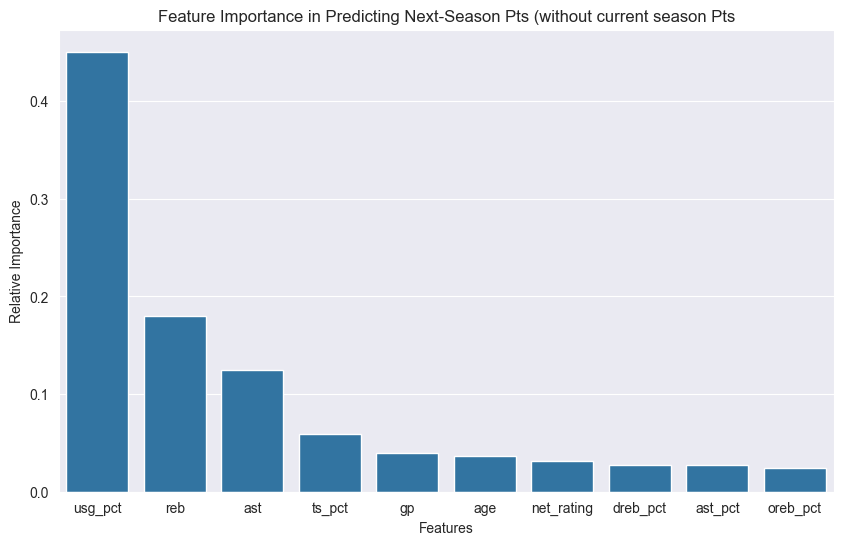

In [104]:
plt.figure(figsize=(10,6))

plt.title("Feature Importance in Predicting Next-Season Pts (without current season Pts")

sns.barplot(x=important_features_nopts.index, y=important_features_nopts)

plt.xlabel("Features")
plt.ylabel("Relative Importance")

plt.show()

We still have heavy right skew, but it is not as dominant this time. This makes sense because usg_pct, which is player usage percentage, indicates who dominates the offense and who the team utilizes most to make plays. This would lead to an increase in average points. This could be considered data leakage, however, because it might be a post-season average that is affected by points per game.

The heavy right skew indicates that tree-based models will most likely work better than another modeling technique like linear regression, since the data does not seem to be linear.

## Cross Validation

The next technique I want to employ is cross validation to assess the model quality through multiple folds.

In [109]:
from sklearn.model_selection import cross_val_score

scores = -1 * cross_val_score(RandomForestRegressor(n_estimators=50, random_state=5), X, y,
                              cv=5,
                              scoring="neg_mean_absolute_error")

print("Average MAE score:", scores.mean())

Average MAE score: 2.340194337689284
